In [21]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
from IPython.display import display, HTML
import time
import pickle
import os
import sys
import csv
import pandas as pd

## Model (no pressure boundary layer)

In [7]:
def run_simulation(nx, ny, nt):
    # Parámetros adimensionales
    Re, Pr, Ec, Eu = 20.0, 10.0, 0.1, 1.0
    Lx_star, Ly_star = 1.0, 1.0
    dx_star = Lx_star / (nx - 1)
    dy_star = Ly_star / (ny - 1)
    up, u0 = -0.5, 1.0
    T0_star, T1_star = 0.0, 0.0
    #dt_star = 1 / 1100

    x_star = np.linspace(0, Lx_star, nx)
    y_star = np.linspace(0, Ly_star, ny)
    X_star, Y_star = np.meshgrid(x_star, y_star)

    u_star = np.zeros((ny, nx)) + u0
    v_star = np.zeros((ny, nx))
    p_star = np.zeros((ny, nx))
    T_star = np.zeros((ny, nx)) + T1_star

    # Condiciones de frontera iniciales
    u_star[0, :] = up
    u_star[-1, :] = u0
    v_star[0, :] = v_star[-1, :] = 0
    T_star[0, :] = T0_star
    T_star[-1, :] = T1_star

    u_history, v_history, p_history, T_history, tau_history = [], [], [], [], []

    for n in range(nt):
        u_old, v_old, p_old, T_old = u_star.copy(), v_star.copy(), p_star.copy(), T_star.copy()

        # Verificación CFL
        u_max = np.max(np.abs(u_old))
        v_max = np.max(np.abs(v_old))

        # Ajuste dinámico del dt_star para mantener CFL < 1
        cfl_max = 0.5
        dt_star = cfl_max * min(dx_star / (u_max + 1e-8), dy_star / (v_max + 1e-8))

        # Verificación CFL (ahora solo informativa)
        cfl_x = u_max * dt_star / dx_star
        cfl_y = v_max * dt_star / dy_star
        if cfl_x > 1.0 or cfl_y > 1.0:
            print(f"Advertencia: condición CFL violada en paso {n}: CFLx={cfl_x:.2f}, CFLy={cfl_y:.2f}")

        # Ecuaciones de momento
        for i in range(1, ny - 1):
            for j in range(1, nx - 1):
                conv_u_x = u_old[i, j] * (u_old[i, j + 1] - u_old[i, j - 1]) / (2 * dx_star)
                conv_u_y = v_old[i, j] * (u_old[i + 1, j] - u_old[i - 1, j]) / (2 * dy_star)
                diff_u = ((u_old[i, j + 1] - 2 * u_old[i, j] + u_old[i, j - 1]) / dx_star ** 2 +
                          (u_old[i + 1, j] - 2 * u_old[i, j] + u_old[i - 1, j]) / dy_star ** 2)

                u_star[i, j] = u_old[i, j] + dt_star * (-conv_u_x - conv_u_y + (1 / Re) * diff_u)

                conv_v_x = u_old[i, j] * (v_old[i, j + 1] - v_old[i, j - 1]) / (2 * dx_star)
                conv_v_y = v_old[i, j] * (v_old[i + 1, j] - v_old[i - 1, j]) / (2 * dy_star)
                diff_v = ((v_old[i, j + 1] - 2 * v_old[i, j] + v_old[i, j - 1]) / dx_star ** 2 +
                          (v_old[i + 1, j] - 2 * v_old[i, j] + v_old[i - 1, j]) / dy_star ** 2)
                grad_p_y = (p_old[i + 1, j] - p_old[i - 1, j]) / (2 * dy_star)

                v_star[i, j] = v_old[i, j] + dt_star * (-conv_v_x - conv_v_y - Eu * grad_p_y + (1 / Re) * diff_v)

        # Solver de presión con criterio de convergencia
        for _ in range(200):  # Iteraciones máximas
            max_diff = 0.0
            for i in range(1, ny - 1):
                for j in range(1, nx - 1):
                    rhs = ((u_star[i, j + 1] - u_star[i, j - 1]) / (2 * dx_star) +
                           (v_star[i + 1, j] - v_star[i - 1, j]) / (2 * dy_star))
                    new_p = 0.25 * (p_old[i + 1, j] + p_old[i - 1, j] + p_old[i, j + 1] + p_old[i, j - 1] -
                                    (dx_star * dy_star) / (2 * (dx_star ** 2 + dy_star ** 2)) * rhs)
                    max_diff = max(max_diff, abs(new_p - p_star[i, j]))
                    p_star[i, j] = new_p
            if max_diff < 1e-4:
                break

        # Corregir velocidades con presión
        for i in range(1, ny - 1):
            for j in range(1, nx - 1):
                u_star[i, j] -= dt_star * Eu * (p_star[i, j + 1] - p_star[i, j - 1]) / (2 * dx_star)
                v_star[i, j] -= dt_star * Eu * (p_star[i + 1, j] - p_star[i - 1, j]) / (2 * dy_star)

        # Ecuación de energía
        for i in range(1, ny - 1):
            for j in range(1, nx - 1):
                conv_T_x = u_star[i, j] * (T_old[i, j + 1] - T_old[i, j - 1]) / (2 * dx_star)
                conv_T_y = v_star[i, j] * (T_old[i + 1, j] - T_old[i - 1, j]) / (2 * dy_star)
                diff_T = ((T_old[i, j + 1] - 2 * T_old[i, j] + T_old[i, j - 1]) / dx_star ** 2 +
                          (T_old[i + 1, j] - 2 * T_old[i, j] + T_old[i - 1, j]) / dy_star ** 2)

                Sxx = (u_star[i, j + 1] - u_star[i, j - 1]) / (2 * dx_star)
                Syy = (v_star[i + 1, j] - v_star[i - 1, j]) / (2 * dy_star)
                Sxy = 0.5 * ((u_star[i + 1, j] - u_star[i - 1, j]) / (2 * dy_star) +
                             (v_star[i, j + 1] - v_star[i, j - 1]) / (2 * dx_star))
                viscous_heating = (Ec / Re) * (2 * (Sxx ** 2 + Syy ** 2) + 4 * Sxy ** 2)

                T_star[i, j] = T_old[i, j] + dt_star * (-conv_T_x - conv_T_y +
                                                       (1 / (Re * Pr)) * diff_T + viscous_heating)

        # Shear stress
        tau = np.zeros_like(u_star)
        tau[1:-1, :] = (u_star[2:, :] - u_star[:-2, :]) / (2 * dy_star)

        # Condiciones de frontera actualizadas
        u_star[0, :] = up
        u_star[-1, :] = u0
        u_star[:, -1] = u_star[:, -2]  # Neumann en x=Lx
        v_star[0, :] = v_star[-1, :] = 0
        v_star[:, -1] = 0

        p_star[:, 0] = p_star[:, 1]
        p_star[:, -1] = p_star[:, -2]
        p_star[0, :] = p_star[1, :]
        p_star[-1, :] = p_star[-2, :]

        if n % 10 == 0:
            print(f"\rSimulación en progreso: paso {n}/{nt}", end="")
            sys.stdout.flush()
            u_history.append(u_star.copy())
            v_history.append(v_star.copy())
            p_history.append(p_star.copy())
            T_history.append(T_star.copy())
            tau_history.append(tau.copy())
    print("\rSimulación finalizada.                      ")

    return {
        "u_history": u_history,
        "v_history": v_history,
        "p_history": p_history,
        "T_history": T_history,
        "tau_history": tau_history,
        "params": {"nx": nx, "ny": ny, "dt_star": dt_star, "nt": nt},
        "X_star": X_star,
        "Y_star": Y_star
    }


## Boundary layer thickness

In [25]:
def calcular_boundary_layer_thickness(u, y, u0=1.0):
    perfil = u[:, u.shape[1] // 2]
    for i in range(len(perfil)):
        if perfil[i] >= 0.99 * u0:
            return y[i]
    return y[-1]  # En caso de que nunca alcance 99%


## Pressure coef

In [26]:
def calcular_coeficiente_presion_medio(p):
    return np.mean(p[:, 0])  # Promedio en la pared izquierda, por ejemplo


## Mean temperature

In [27]:
def calcular_temperatura_media(T):
    return np.mean(T)

## Convergence

Simulación finalizada.                      
Simulación finalizada.                      
Simulación finalizada.                      

Convergencia de resolución:
Resolución | Espesor δ | Cp medio | Temp media
     50x50 | 0.48980 | 25.01561 | 0.31767
   100x100 | 0.67677 | 45.27178 | 0.92454
   200x200 | 1.00000 | 31.33446 | 2.40077

Ordenes de convergencia:
δ: -0.790, Cp: nan, Temp: -1.282

GCI (con Fs = 1.25):
GCI_δ: -9.584e-01, GCI_Cp: nan, GCI_T: -1.305e+00


/var/folders/lx/vhxvbgp94fj63r8wrldf_13m0000gn/T/ipykernel_7032/3587298224.py:3: RuntimeWarning: invalid value encountered in log
  return np.log((f3 - f2) / (f2 - f1)) / np.log(r)


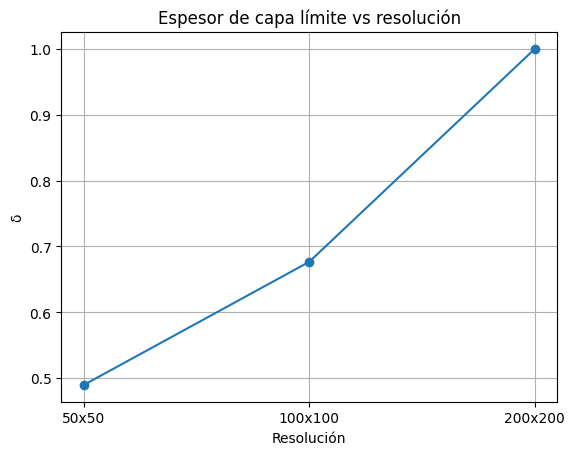

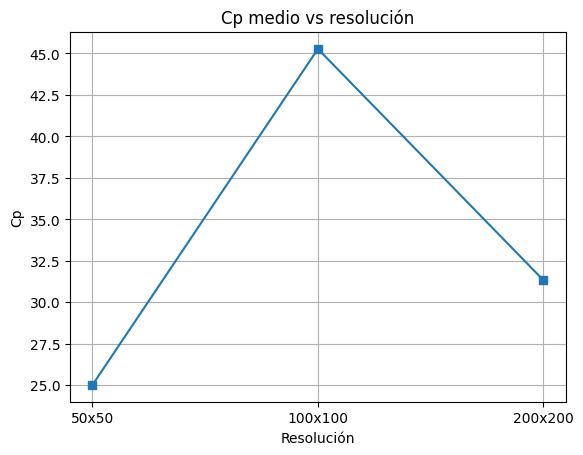

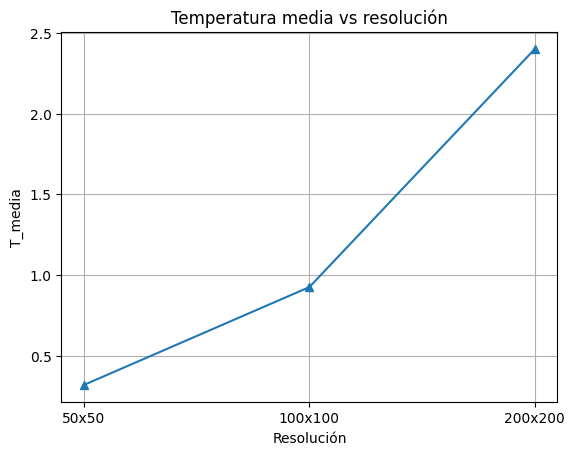

In [10]:
# Orden de convergencia y GCI
def orden_convergencia(f1, f2, f3, r):
    return np.log((f3 - f2) / (f2 - f1)) / np.log(r)

def GCI(f1, f2, r, p, Fs=1.25):
    return Fs * abs(f1 - f2) / abs(f1) / (r**p - 1)

# --- Configuración de mallas y ejecución ---
resoluciones = [(50, 50), (100, 100),(200,200)]
nt = 500
resultados = []

for nx, ny in resoluciones:
    sim = run_simulation(nx, ny, nt)
    u = sim["u_history"][-1]
    p = sim["p_history"][-1]
    T = sim["T_history"][-1]
    y = sim["Y_star"][:, 0]

    delta = calcular_boundary_layer_thickness(u, y)
    cp = calcular_coeficiente_presion_medio(p)
    Tavg = calcular_temperatura_media(T)

    resultados.append({
        "res": f"{nx}x{ny}",
        "delta": delta,
        "Cp": cp,
        "Tavg": Tavg
    })

# --- Análisis de convergencia ---
f_delta = [r["delta"] for r in resultados]
f_cp = [r["Cp"] for r in resultados]
f_T = [r["Tavg"] for r in resultados]

r = 2  # relación entre mallas
p_delta = orden_convergencia(f_delta[2], f_delta[1], f_delta[0], r)
p_cp = orden_convergencia(f_cp[2], f_cp[1], f_cp[0], r)
p_T = orden_convergencia(f_T[2], f_T[1], f_T[0], r)

gci_delta = GCI(f_delta[2], f_delta[1], r, p_delta)
gci_cp = GCI(f_cp[2], f_cp[1], r, p_cp)
gci_T = GCI(f_T[2], f_T[1], r, p_T)

# --- Mostrar resultados ---
print("\nConvergencia de resolución:")
print("Resolución | Espesor δ | Cp medio | Temp media")
for r in resultados:
    print(f"{r['res']:>10} | {r['delta']:.5f} | {r['Cp']:.5f} | {r['Tavg']:.5f}")

print("\nOrdenes de convergencia:")
print(f"δ: {p_delta:.3f}, Cp: {p_cp:.3f}, Temp: {p_T:.3f}")

print("\nGCI (con Fs = 1.25):")
print(f"GCI_δ: {gci_delta:.3e}, GCI_Cp: {gci_cp:.3e}, GCI_T: {gci_T:.3e}")

# --- Gráficos (opcional) ---
res_labels = [r["res"] for r in resultados]

plt.figure()
plt.plot(res_labels, f_delta, marker='o')
plt.title("Espesor de capa límite vs resolución")
plt.ylabel("δ")
plt.xlabel("Resolución")
plt.grid()

plt.figure()
plt.plot(res_labels, f_cp, marker='s')
plt.title("Cp medio vs resolución")
plt.ylabel("Cp")
plt.xlabel("Resolución")
plt.grid()

plt.figure()
plt.plot(res_labels, f_T, marker='^')
plt.title("Temperatura media vs resolución")
plt.ylabel("T_media")
plt.xlabel("Resolución")
plt.grid()

plt.show()

Simulación finalizada.                      
Simulación finalizada.                      
Simulación finalizada.                      
Simulación finalizada.                      
Simulación finalizada.                      
Simulación finalizada.                      
Simulación finalizada.                      

Convergencia de resolución:
Resolución | Espesor δ | Cp medio | Temp media
     25x25 | 0.75000 | 28.82221 | 0.11804
     50x50 | 0.48980 | 25.01561 | 0.31767
   100x100 | 0.67677 | 45.27178 | 0.92454
   200x200 | 1.00000 | 31.33446 | 2.40077
   400x400 | 0.77945 | 8.72101 | 2.16325
   800x800 | 0.05757 | -1.49218 | 2.46061
 1600x1600 | 0.03002 | 27.75678 | 5.67864

Ordenes de convergencia:
δ: nan, Cp: nan, Temp: -1.604

GCI (con Fs = 1.25):
GCI_δ: nan, GCI_Cp: nan, GCI_T: -1.223e+00


/var/folders/lx/vhxvbgp94fj63r8wrldf_13m0000gn/T/ipykernel_7032/2783843754.py:3: RuntimeWarning: invalid value encountered in log
  return np.log((f3 - f2) / (f2 - f1)) / np.log(r)


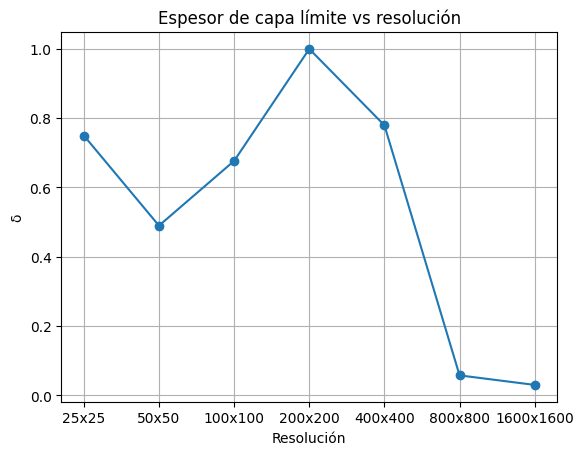

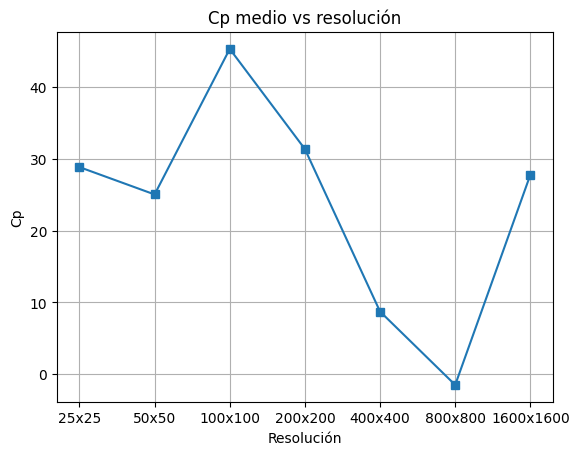

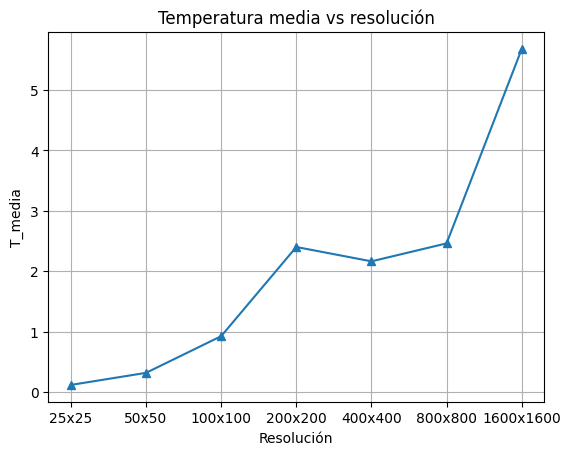

In [12]:
# Orden de convergencia y GCI
def orden_convergencia(f1, f2, f3, r):
    return np.log((f3 - f2) / (f2 - f1)) / np.log(r)

def GCI(f1, f2, r, p, Fs=1.25):
    return Fs * abs(f1 - f2) / abs(f1) / (r**p - 1)

# --- Configuración de mallas y ejecución ---
resoluciones = [(25, 25), (50, 50), (100, 100),(200,200), (400,400), (800, 800), (1600,1600)]
nt = 500
resultados = []

for nx, ny in resoluciones:
    sim = run_simulation(nx, ny, nt)
    u = sim["u_history"][-1]
    p = sim["p_history"][-1]
    T = sim["T_history"][-1]
    y = sim["Y_star"][:, 0]

    delta = calcular_boundary_layer_thickness(u, y)
    cp = calcular_coeficiente_presion_medio(p)
    Tavg = calcular_temperatura_media(T)

    resultados.append({
        "res": f"{nx}x{ny}",
        "delta": delta,
        "Cp": cp,
        "Tavg": Tavg
    })

# --- Análisis de convergencia ---
f_delta = [r["delta"] for r in resultados]
f_cp = [r["Cp"] for r in resultados]
f_T = [r["Tavg"] for r in resultados]

r = 2  # relación entre mallas
p_delta = orden_convergencia(f_delta[2], f_delta[1], f_delta[0], r)
p_cp = orden_convergencia(f_cp[2], f_cp[1], f_cp[0], r)
p_T = orden_convergencia(f_T[2], f_T[1], f_T[0], r)

gci_delta = GCI(f_delta[2], f_delta[1], r, p_delta)
gci_cp = GCI(f_cp[2], f_cp[1], r, p_cp)
gci_T = GCI(f_T[2], f_T[1], r, p_T)

# --- Mostrar resultados ---
print("\nConvergencia de resolución:")
print("Resolución | Espesor δ | Cp medio | Temp media")
for r in resultados:
    print(f"{r['res']:>10} | {r['delta']:.5f} | {r['Cp']:.5f} | {r['Tavg']:.5f}")

print("\nOrdenes de convergencia:")
print(f"δ: {p_delta:.3f}, Cp: {p_cp:.3f}, Temp: {p_T:.3f}")

print("\nGCI (con Fs = 1.25):")
print(f"GCI_δ: {gci_delta:.3e}, GCI_Cp: {gci_cp:.3e}, GCI_T: {gci_T:.3e}")

# --- Gráficos (opcional) ---
res_labels = [r["res"] for r in resultados]

plt.figure()
plt.plot(res_labels, f_delta, marker='o')
plt.title("Espesor de capa límite vs resolución")
plt.ylabel("δ")
plt.xlabel("Resolución")
plt.grid()

plt.figure()
plt.plot(res_labels, f_cp, marker='s')
plt.title("Cp medio vs resolución")
plt.ylabel("Cp")
plt.xlabel("Resolución")
plt.grid()

plt.figure()
plt.plot(res_labels, f_T, marker='^')
plt.title("Temperatura media vs resolución")
plt.ylabel("T_media")
plt.xlabel("Resolución")
plt.grid()

plt.show()

In [14]:
# Guardar los resultados en un archivo CSV
nombre_archivo = "convergencia_resultados.csv"

with open(nombre_archivo, mode='w', newline='') as archivo:
    writer = csv.writer(archivo)
    writer.writerow(["Resolucion", "Espesor_delta", "Cp_medio", "Temp_media"])

    for r in resultados:
        writer.writerow([r['res'], r['delta'], r['Cp'], r['Tavg']])

print(f"\n✅ Resultados guardados en '{nombre_archivo}'")



✅ Resultados guardados en 'convergencia_resultados.csv'


In [11]:
# Cargar archivo de resultados
convergencia_resultados = pd.read_csv("convergencia_resultados.csv")


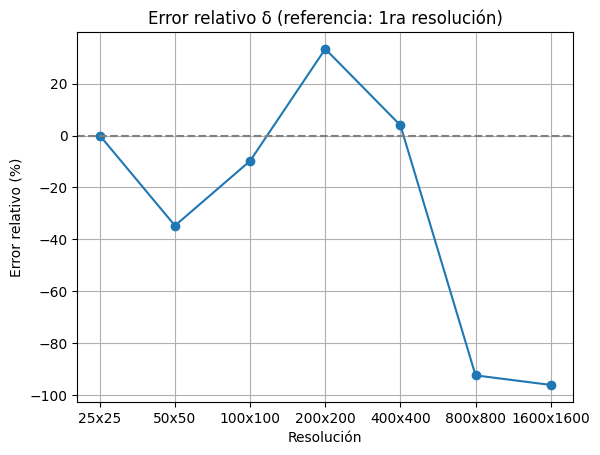

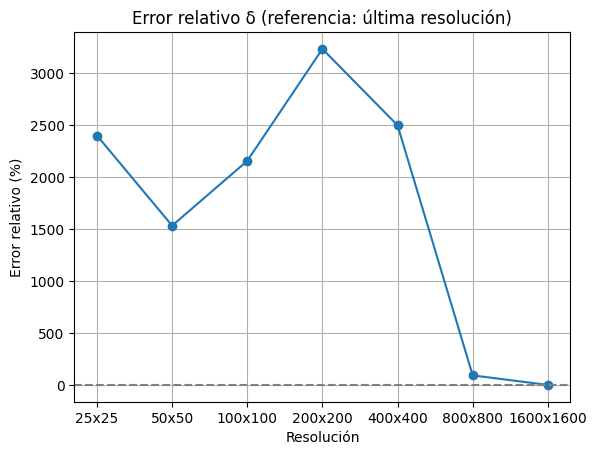

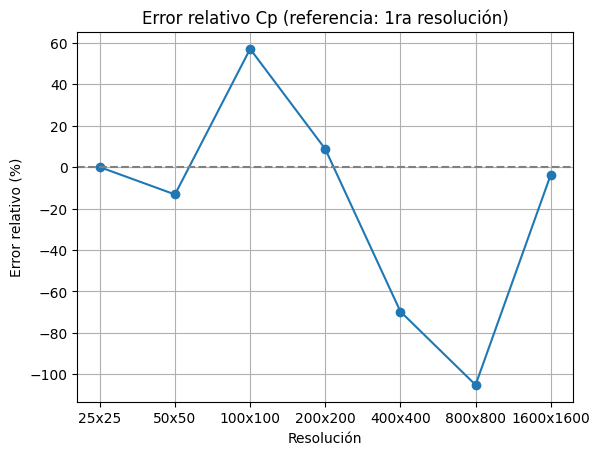

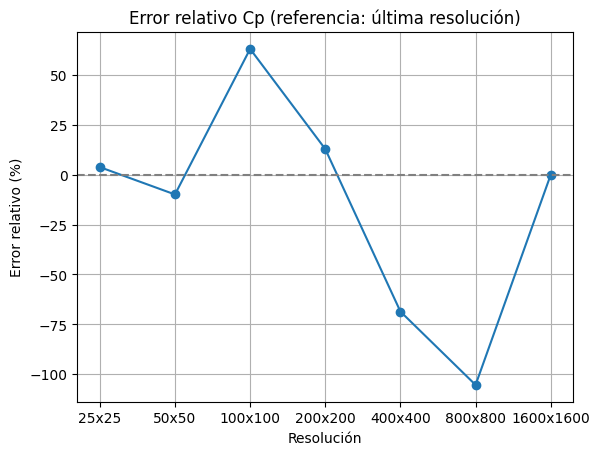

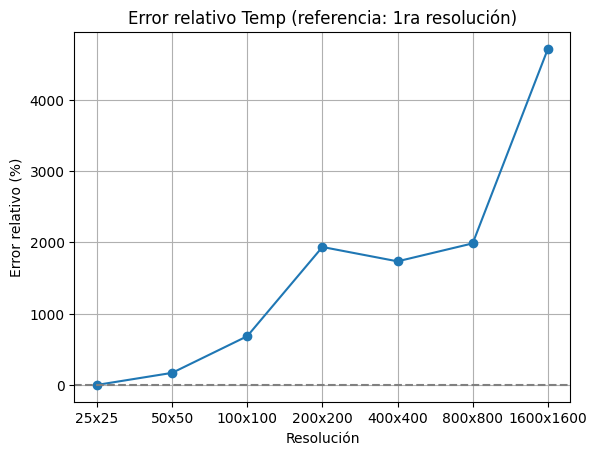

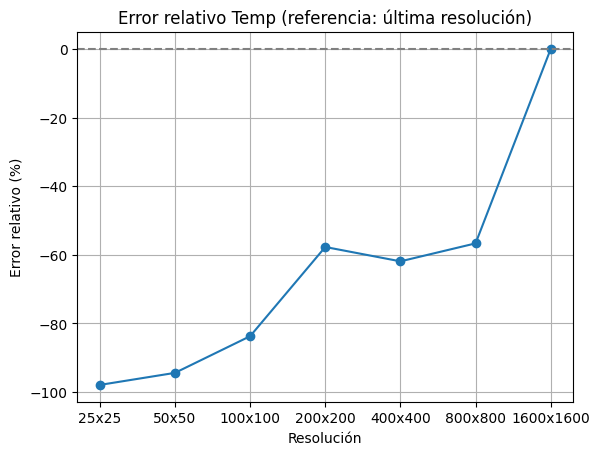

In [12]:
# --- Cálculo de errores relativos porcentuales ---

def calcular_errores_relativos(valores, referencia):
    return [100 * (v - referencia) / referencia for v in valores]

# Extraer resoluciones y datos
res_labels = convergencia_resultados["Resolucion"].tolist()
delta_vals = convergencia_resultados["Espesor_delta"].tolist()
cp_vals = convergencia_resultados["Cp_medio"].tolist()
T_vals = convergencia_resultados["Temp_media"].tolist()


# Errores relativos
errores_delta_inicio = calcular_errores_relativos(delta_vals, delta_vals[0])
errores_delta_fin = calcular_errores_relativos(delta_vals, delta_vals[-1])

errores_cp_inicio = calcular_errores_relativos(cp_vals, cp_vals[0])
errores_cp_fin = calcular_errores_relativos(cp_vals, cp_vals[-1])

errores_T_inicio = calcular_errores_relativos(T_vals, T_vals[0])
errores_T_fin = calcular_errores_relativos(T_vals, T_vals[-1])

# --- Graficar errores relativos ---
def graficar_error(titulo, errores, resoluciones, ref_pos):
    plt.figure()
    plt.plot(resoluciones, errores, marker='o')
    plt.axhline(0, color='gray', linestyle='--')
    plt.title(f"{titulo} (referencia: {'1ra' if ref_pos == 'inicio' else 'última'} resolución)")
    plt.ylabel("Error relativo (%)")
    plt.xlabel("Resolución")
    plt.grid()

graficar_error("Error relativo δ", errores_delta_inicio, res_labels, "inicio")
graficar_error("Error relativo δ", errores_delta_fin, res_labels, "fin")

graficar_error("Error relativo Cp", errores_cp_inicio, res_labels, "inicio")
graficar_error("Error relativo Cp", errores_cp_fin, res_labels, "fin")

graficar_error("Error relativo Temp", errores_T_inicio, res_labels, "inicio")
graficar_error("Error relativo Temp", errores_T_fin, res_labels, "fin")

plt.show()
